# VisA DINOv2 Patch Anomaly Detection and Localization

This notebook validates the vision architecture on one industrial-looking VisA
class before the same pipeline is applied to synthetic mechanical defects.

Default class: `pcb1`

Pipeline:

```text
normal training images
  -> DINOv2 patch tokens
  -> bounded normal patch memory bank

test image
  -> DINOv2 patch tokens
  -> nearest-normal cosine distance per patch
  -> anomaly heatmap
  -> image anomaly score
```

The CLS token is not used for localization. Patch tokens are required to retain
spatial information.

VisA `pcb1` is an industrial proxy for validating anomaly detection and
localization. It is not presented as robot-joint, bearing, or gearbox training
data.


## 1. Environment and Configuration

Run the package cell only if dependencies are missing. PyTorch must already be
the ROCm build on the AMD server.


In [1]:
# Run only when needed:
%pip install "numpy<2.3" "pandas<3" "scikit-learn<2" \ pillow matplotlib seaborn transformers



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    jaccard_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from transformers import AutoImageProcessor, AutoModel

SEED = 42
CLASS_NAME = "pcb1"
MODEL_NAME = "facebook/dinov2-base"
IMAGE_SIZE = 224
BATCH_SIZE = 8
MAX_MEMORY_PATCHES = 30000
SIMILARITY_CHUNK_SIZE = 5000
TOP_PATCH_FRACTION = 0.05
PIXEL_AUC_SAMPLE_LIMIT = 2_000_000

NORMAL_MEMORY_FRACTION = 0.70
NORMAL_CALIBRATION_FRACTION = 0.15
ANOMALY_CALIBRATION_FRACTION = 0.50

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid")

DATA_ROOT = Path("../data") if Path.cwd().name == "vision" else Path("data")
VISA_DIR = DATA_ROOT / "VisA"
ARTIFACT_ROOT = Path("artifacts/visa")
MANIFEST_PATH = ARTIFACT_ROOT / "visa_manifest.csv"
RUN_DIR = ARTIFACT_ROOT / "dinov2" / CLASS_NAME
FIGURE_DIR = RUN_DIR / "figures"
RUN_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True

print("Working directory:", Path.cwd().resolve())
print("Dataset:", VISA_DIR.resolve())
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Working directory: /workspace/notebooks/vision
Dataset: /workspace/notebooks/data/VisA
Device: cuda
GPU: 


## 2. Load the Validated Manifest

This notebook expects `visa_manifest.csv` from the preparation notebook.


In [3]:
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {MANIFEST_PATH}. Run the VisA preparation notebook first."
    )

manifest = pd.read_csv(MANIFEST_PATH).fillna("")
class_manifest = manifest[
    manifest["class_name"] == CLASS_NAME
].reset_index(drop=True)

normal_manifest = class_manifest[
    class_manifest["label"] == "normal"
].reset_index(drop=True)
anomaly_manifest = class_manifest[
    class_manifest["label"] == "anomaly"
].reset_index(drop=True)

if normal_manifest.empty or anomaly_manifest.empty:
    raise ValueError(f"Class {CLASS_NAME} has incomplete manifest records.")

for relative_path in class_manifest["image_path"]:
    if not (VISA_DIR / relative_path).is_file():
        raise FileNotFoundError(VISA_DIR / relative_path)

print("Class:", CLASS_NAME)
print("Normal images:", len(normal_manifest))
print("Anomaly images:", len(anomaly_manifest))


Class: pcb1
Normal images: 1004
Anomaly images: 100


## 3. Leakage-Safe Data Splits

Normal images are divided into memory, calibration, and test groups. Anomalies
are divided between calibration and test. Thresholds are selected on calibration
data only.


In [4]:
def shuffled_indices(length: int, seed: int):
    indices = np.arange(length)
    generator = np.random.default_rng(seed)
    generator.shuffle(indices)
    return indices


normal_indices = shuffled_indices(len(normal_manifest), SEED)
normal_memory_end = int(len(normal_indices) * NORMAL_MEMORY_FRACTION)
normal_calibration_end = normal_memory_end + int(
    len(normal_indices) * NORMAL_CALIBRATION_FRACTION
)

normal_memory = normal_manifest.iloc[
    normal_indices[:normal_memory_end]
].reset_index(drop=True)
normal_calibration = normal_manifest.iloc[
    normal_indices[normal_memory_end:normal_calibration_end]
].reset_index(drop=True)
normal_test = normal_manifest.iloc[
    normal_indices[normal_calibration_end:]
].reset_index(drop=True)

anomaly_indices = shuffled_indices(len(anomaly_manifest), SEED + 1)
anomaly_calibration_end = int(
    len(anomaly_indices) * ANOMALY_CALIBRATION_FRACTION
)
anomaly_calibration = anomaly_manifest.iloc[
    anomaly_indices[:anomaly_calibration_end]
].reset_index(drop=True)
anomaly_test = anomaly_manifest.iloc[
    anomaly_indices[anomaly_calibration_end:]
].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "normal_memory", "count": len(normal_memory)},
        {"split": "normal_calibration", "count": len(normal_calibration)},
        {"split": "normal_test", "count": len(normal_test)},
        {"split": "anomaly_calibration", "count": len(anomaly_calibration)},
        {"split": "anomaly_test", "count": len(anomaly_test)},
    ]
)
display(split_summary)

assert len(normal_memory) + len(normal_calibration) + len(normal_test) == len(
    normal_manifest
)
assert len(anomaly_calibration) + len(anomaly_test) == len(anomaly_manifest)


,split,count
0,normal_memory,702
1,normal_calibration,150
2,normal_test,152
3,anomaly_calibration,50
4,anomaly_test,50


## 4. Load DINOv2 on ROCm


In [5]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
    crop_size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

patch_size = int(model.config.patch_size)
grid_height = IMAGE_SIZE // patch_size
grid_width = IMAGE_SIZE // patch_size
patch_count = grid_height * grid_width
embedding_dimension = int(model.config.hidden_size)

print("Model:", MODEL_NAME)
print("Patch size:", patch_size)
print("Patch grid:", (grid_height, grid_width))
print("Patch count:", patch_count)
print("Embedding dimension:", embedding_dimension)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model: facebook/dinov2-base
Patch size: 14
Patch grid: (16, 16)
Patch count: 256
Embedding dimension: 768


## 5. Patch-Embedding Utilities


In [6]:
def load_rgb(relative_path: str) -> Image.Image:
    return Image.open(VISA_DIR / relative_path).convert("RGB")


def extract_patch_embeddings(paths, batch_size=BATCH_SIZE):
    all_embeddings = []

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start : start + batch_size]
        images = [load_rgb(path) for path in batch_paths]
        inputs = processor(images=images, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(DEVICE)

        with torch.inference_mode():
            outputs = model(pixel_values=pixel_values)
            # Token 0 is CLS. Remaining tokens preserve patch locations.
            patches = outputs.last_hidden_state[:, 1:, :]
            patches = F.normalize(patches.float(), dim=-1)

        if patches.shape[1] != patch_count:
            raise ValueError(
                f"Expected {patch_count} patches, received {patches.shape[1]}."
            )
        all_embeddings.append(patches.cpu())

    return torch.cat(all_embeddings, dim=0)


def nearest_memory_distance(query_patches, memory_bank):
    query_patches = query_patches.to(DEVICE)
    best_similarity = torch.full(
        (query_patches.shape[0],),
        -1.0,
        device=DEVICE,
    )

    for start in range(0, len(memory_bank), SIMILARITY_CHUNK_SIZE):
        memory_chunk = memory_bank[
            start : start + SIMILARITY_CHUNK_SIZE
        ].to(DEVICE)
        similarity = query_patches @ memory_chunk.T
        best_similarity = torch.maximum(
            best_similarity,
            similarity.max(dim=1).values,
        )

    return (1.0 - best_similarity).clamp(min=0).cpu()


def image_score_from_patch_scores(patch_scores):
    top_count = max(
        1,
        int(math.ceil(len(patch_scores) * TOP_PATCH_FRACTION)),
    )
    return float(torch.topk(patch_scores, top_count).values.mean())


## 6. Build the Normal Patch Memory Bank

The full patch collection can be large. A seeded random sample keeps memory and
similarity computation bounded and reproducible.


In [10]:
start_time = time.perf_counter()
normal_patch_batches = []

memory_paths = normal_memory["image_path"].tolist()
for start in range(0, len(memory_paths), BATCH_SIZE):
    embeddings = extract_patch_embeddings(
        memory_paths[start : start + BATCH_SIZE]
    )
    normal_patch_batches.append(
        embeddings.reshape(-1, embedding_dimension)
    )

all_normal_patches = torch.cat(normal_patch_batches, dim=0)
generator = torch.Generator().manual_seed(SEED)

if len(all_normal_patches) > MAX_MEMORY_PATCHES:
    selected = torch.randperm(
        len(all_normal_patches),
        generator=generator,
    )[:MAX_MEMORY_PATCHES]
    memory_bank = all_normal_patches[selected].contiguous()
else:
    memory_bank = all_normal_patches.contiguous()

memory_seconds = time.perf_counter() - start_time
print("All extracted normal patches:", len(all_normal_patches))
print("Memory-bank patches:", len(memory_bank))
print("Memory-bank shape:", tuple(memory_bank.shape))
print(f"Memory-bank build time: {memory_seconds:.1f} seconds")

del all_normal_patches
del normal_patch_batches
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


All extracted normal patches: 179712
Memory-bank patches: 30000
Memory-bank shape: (30000, 768)
Memory-bank build time: 19.6 seconds


## 7. Score Images and Generate Patch Maps


In [8]:
def score_manifest_rows(rows: pd.DataFrame):
    records = []
    patch_maps = {}
    paths = rows["image_path"].tolist()

    for start in range(0, len(paths), BATCH_SIZE):
        batch_rows = rows.iloc[start : start + BATCH_SIZE]
        batch_paths = batch_rows["image_path"].tolist()
        batch_embeddings = extract_patch_embeddings(batch_paths)

        for local_index, (_, row) in enumerate(batch_rows.iterrows()):
            patch_scores = nearest_memory_distance(
                batch_embeddings[local_index],
                memory_bank,
            )
            patch_map = patch_scores.reshape(grid_height, grid_width).numpy()
            image_score = image_score_from_patch_scores(patch_scores)

            records.append(
                {
                    "class_name": row["class_name"],
                    "label": row["label"],
                    "image_path": row["image_path"],
                    "mask_path": row["mask_path"],
                    "image_score": image_score,
                }
            )
            patch_maps[row["image_path"]] = patch_map

    return pd.DataFrame(records), patch_maps


normal_calibration_scores, normal_calibration_maps = score_manifest_rows(
    normal_calibration
)
anomaly_calibration_scores, anomaly_calibration_maps = score_manifest_rows(
    anomaly_calibration
)

calibration_scores = pd.concat(
    [normal_calibration_scores, anomaly_calibration_scores],
    ignore_index=True,
)
calibration_maps = {
    **normal_calibration_maps,
    **anomaly_calibration_maps,
}

display(
    calibration_scores.groupby("label")["image_score"].describe()
)


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
anomaly,50.0,0.172286,0.072530,0.107026,0.126995,0.145956,0.175188,0.481187
normal,150.0,0.109800,0.019363,0.074571,0.096045,0.105985,0.120595,0.194825


## 8. Calibrate the Image-Level Threshold


In [9]:
def best_f1_threshold(labels, scores):
    candidates = np.unique(scores)
    best = None
    for threshold in candidates:
        predictions = (scores >= threshold).astype(int)
        result = {
            "threshold": float(threshold),
            "precision": float(
                precision_score(labels, predictions, zero_division=0)
            ),
            "recall": float(
                recall_score(labels, predictions, zero_division=0)
            ),
            "f1": float(f1_score(labels, predictions, zero_division=0)),
        }
        if best is None or result["f1"] > best["f1"]:
            best = result
    return best


calibration_labels = (
    calibration_scores["label"] == "anomaly"
).astype(int).to_numpy()
calibration_image_values = calibration_scores["image_score"].to_numpy()
image_threshold_metrics = best_f1_threshold(
    calibration_labels,
    calibration_image_values,
)
IMAGE_THRESHOLD = image_threshold_metrics["threshold"]

calibration_image_metrics = {
    **image_threshold_metrics,
    "roc_auc": float(
        roc_auc_score(calibration_labels, calibration_image_values)
    ),
    "pr_auc": float(
        average_precision_score(
            calibration_labels,
            calibration_image_values,
        )
    ),
}
display(pd.DataFrame([calibration_image_metrics]))


,threshold,precision,recall,f1,roc_auc,pr_auc
0,0.125469,0.617647,0.84,0.711864,0.905333,0.78166


## 9. Calibrate the Pixel Threshold

Masks are resized to the DINOv2 patch grid. The threshold is selected using
calibration anomalies only and is then frozen for test localization.


In [11]:
def load_patch_mask(mask_path: str):
    mask = Image.open(VISA_DIR / mask_path).convert("L")
    mask = mask.resize(
        (grid_width, grid_height),
        resample=Image.Resampling.NEAREST,
    )
    return (np.asarray(mask) > 0).astype(np.uint8)


calibration_pixel_scores = []
calibration_pixel_labels = []

for _, row in anomaly_calibration_scores.iterrows():
    calibration_pixel_scores.append(
        calibration_maps[row["image_path"]].reshape(-1)
    )
    calibration_pixel_labels.append(
        load_patch_mask(row["mask_path"]).reshape(-1)
    )

calibration_pixel_scores = np.concatenate(calibration_pixel_scores)
calibration_pixel_labels = np.concatenate(calibration_pixel_labels)
pixel_threshold_metrics = best_f1_threshold(
    calibration_pixel_labels,
    calibration_pixel_scores,
)
PIXEL_THRESHOLD = pixel_threshold_metrics["threshold"]

display(pd.DataFrame([pixel_threshold_metrics]))


,threshold,precision,recall,f1
0,0.24516,0.541985,0.763441,0.633929


## 10. Official Test Evaluation


,roc_auc,pr_auc,precision,recall,f1,false_alarms,missed_anomalies
0,0.854737,0.71717,0.527778,0.76,0.622951,34,12


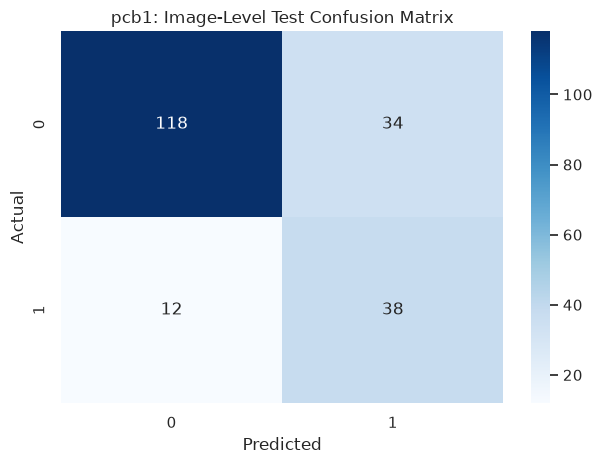

In [13]:
normal_test_scores, normal_test_maps = score_manifest_rows(normal_test)
anomaly_test_scores, anomaly_test_maps = score_manifest_rows(anomaly_test)

test_scores = pd.concat(
    [normal_test_scores, anomaly_test_scores],
    ignore_index=True,
)
test_maps = {**normal_test_maps, **anomaly_test_maps}

test_labels = (test_scores["label"] == "anomaly").astype(int).to_numpy()
test_image_values = test_scores["image_score"].to_numpy()
test_predictions = (test_image_values >= IMAGE_THRESHOLD).astype(int)

image_test_metrics = {
    "roc_auc": float(roc_auc_score(test_labels, test_image_values)),
    "pr_auc": float(
        average_precision_score(test_labels, test_image_values)
    ),
    "precision": float(
        precision_score(test_labels, test_predictions, zero_division=0)
    ),
    "recall": float(
        recall_score(test_labels, test_predictions, zero_division=0)
    ),
    "f1": float(f1_score(test_labels, test_predictions, zero_division=0)),
    "false_alarms": int(
        ((test_predictions == 1) & (test_labels == 0)).sum()
    ),
    "missed_anomalies": int(
        ((test_predictions == 0) & (test_labels == 1)).sum()
    ),
}
display(pd.DataFrame([image_test_metrics]))

matrix = confusion_matrix(test_labels, test_predictions)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{CLASS_NAME}: Image-Level Test Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "image_confusion_matrix.png", dpi=150)
plt.show()


In [14]:
pixel_scores = []
pixel_labels = []
image_ious = []

for _, row in anomaly_test_scores.iterrows():
    score_map = test_maps[row["image_path"]]
    true_mask = load_patch_mask(row["mask_path"])
    predicted_mask = (score_map >= PIXEL_THRESHOLD).astype(np.uint8)

    pixel_scores.append(score_map.reshape(-1))
    pixel_labels.append(true_mask.reshape(-1))
    image_ious.append(
        jaccard_score(
            true_mask.reshape(-1),
            predicted_mask.reshape(-1),
            zero_division=0,
        )
    )

# Include normal test images as zero masks in pixel-level evaluation.
for _, row in normal_test_scores.iterrows():
    score_map = test_maps[row["image_path"]]
    pixel_scores.append(score_map.reshape(-1))
    pixel_labels.append(np.zeros(score_map.size, dtype=np.uint8))

pixel_scores = np.concatenate(pixel_scores)
pixel_labels = np.concatenate(pixel_labels)

if len(pixel_scores) > PIXEL_AUC_SAMPLE_LIMIT:
    generator = np.random.default_rng(SEED)
    sample_indices = generator.choice(
        len(pixel_scores),
        size=PIXEL_AUC_SAMPLE_LIMIT,
        replace=False,
    )
    auc_scores = pixel_scores[sample_indices]
    auc_labels = pixel_labels[sample_indices]
else:
    auc_scores = pixel_scores
    auc_labels = pixel_labels

pixel_predictions = (pixel_scores >= PIXEL_THRESHOLD).astype(int)
pixel_test_metrics = {
    "pixel_roc_auc": float(roc_auc_score(auc_labels, auc_scores)),
    "pixel_average_precision": float(
        average_precision_score(auc_labels, auc_scores)
    ),
    "pixel_f1": float(
        f1_score(pixel_labels, pixel_predictions, zero_division=0)
    ),
    "mean_anomaly_iou": float(np.mean(image_ious)),
}
display(pd.DataFrame([pixel_test_metrics]))


,pixel_roc_auc,pixel_average_precision,pixel_f1,mean_anomaly_iou
0,0.986846,0.772169,0.736486,0.325613


## 11. Heatmap Visualization


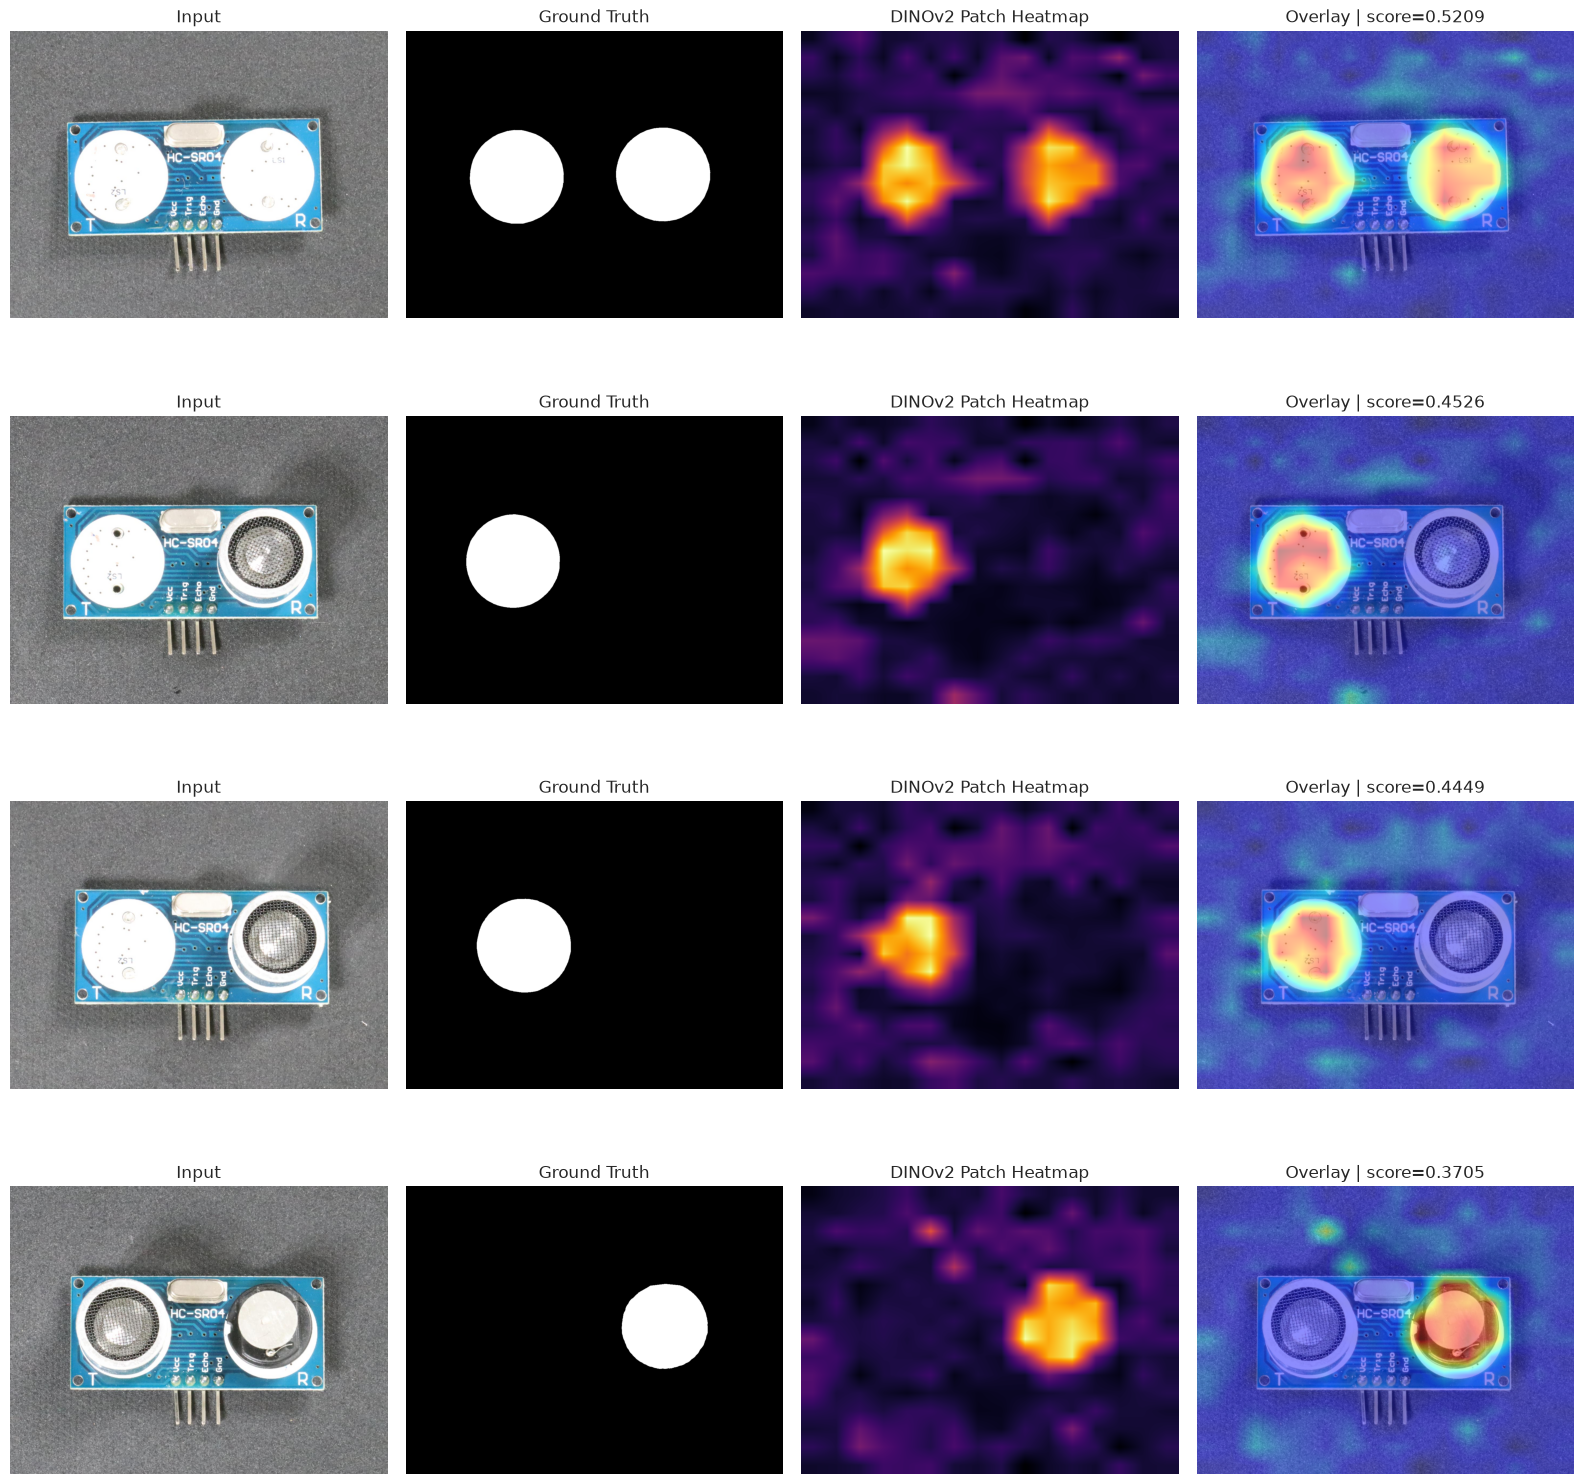

In [15]:
def upsample_heatmap(patch_map, image_size):
    tensor = torch.from_numpy(patch_map)[None, None].float()
    resized = F.interpolate(
        tensor,
        size=(image_size[1], image_size[0]),
        mode="bilinear",
        align_corners=False,
    )
    return resized[0, 0].numpy()


examples = anomaly_test_scores.sort_values(
    "image_score",
    ascending=False,
).head(4)

fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
for row_index, (_, row) in enumerate(examples.iterrows()):
    image = load_rgb(row["image_path"])
    mask = Image.open(VISA_DIR / row["mask_path"]).convert("L")
    heatmap = upsample_heatmap(test_maps[row["image_path"]], image.size)

    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title("Input")
    axes[row_index, 1].imshow(mask, cmap="gray")
    axes[row_index, 1].set_title("Ground Truth")
    axes[row_index, 2].imshow(heatmap, cmap="inferno")
    axes[row_index, 2].set_title("DINOv2 Patch Heatmap")
    axes[row_index, 3].imshow(image)
    axes[row_index, 3].imshow(heatmap, cmap="jet", alpha=0.45)
    axes[row_index, 3].set_title(
        f"Overlay | score={row['image_score']:.4f}"
    )

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "anomaly_heatmaps.png", dpi=150)
plt.show()


## 12. Save Memory Bank, Results, and Vision Contract


In [16]:
test_results = test_scores.copy()
test_results["true_label"] = test_labels
test_results["predicted_label"] = test_predictions
test_results["is_anomaly"] = test_predictions.astype(bool)

memory_path = RUN_DIR / "normal_patch_memory.pt"
results_path = RUN_DIR / "official_test_results.csv"
metadata_path = RUN_DIR / "metadata.json"
contract_path = RUN_DIR / "vision_contract_example.json"

torch.save(
    {
        "memory_bank": memory_bank,
        "model_name": MODEL_NAME,
        "class_name": CLASS_NAME,
        "image_size": IMAGE_SIZE,
        "patch_size": patch_size,
        "grid_height": grid_height,
        "grid_width": grid_width,
    },
    memory_path,
)
test_results.to_csv(results_path, index=False)

top_anomaly = anomaly_test_scores.sort_values(
    "image_score",
    ascending=False,
).iloc[0]
vision_contract = {
    "scenario_id": f"VISA-{CLASS_NAME.upper()}-001",
    "asset_id": f"VISION-{CLASS_NAME.upper()}",
    "anomaly_score": float(top_anomaly["image_score"]),
    "is_anomaly": bool(top_anomaly["image_score"] >= IMAGE_THRESHOLD),
    "predicted_fault": "visual_surface_anomaly",
    "location": "patch_heatmap",
    "image_path": top_anomaly["image_path"],
    "heatmap_artifact": str(
        (FIGURE_DIR / "anomaly_heatmaps.png").as_posix()
    ),
    "evidence": {
        "model": MODEL_NAME,
        "normal_memory_patches": int(len(memory_bank)),
        "image_threshold": IMAGE_THRESHOLD,
        "pixel_threshold": PIXEL_THRESHOLD,
    },
    "limitations": [
        f"The model was calibrated only for the VisA {CLASS_NAME} class.",
        "VisA PCB defects are an architecture-validation proxy, not mechanical robot faults.",
        "Defect type is generic; the baseline localizes anomalies but does not name every defect subtype.",
    ],
}
contract_path.write_text(
    json.dumps(vision_contract, indent=2),
    encoding="utf-8",
)

metadata = {
    "dataset": "Visual Anomaly (VisA)",
    "class_name": CLASS_NAME,
    "model_name": MODEL_NAME,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "patch_size": patch_size,
    "patch_grid": [grid_height, grid_width],
    "embedding_dimension": embedding_dimension,
    "memory_bank_patches": int(len(memory_bank)),
    "image_threshold": IMAGE_THRESHOLD,
    "pixel_threshold": PIXEL_THRESHOLD,
    "calibration_image_metrics": calibration_image_metrics,
    "official_test_image_metrics": image_test_metrics,
    "official_test_pixel_metrics": pixel_test_metrics,
    "split_counts": {
        row["split"]: int(row["count"])
        for _, row in split_summary.iterrows()
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved memory bank:", memory_path.resolve())
print("Saved metadata:", metadata_path.resolve())
print("Saved test results:", results_path.resolve())
print("Saved vision contract:", contract_path.resolve())
print(json.dumps(vision_contract, indent=2))


Saved memory bank: /workspace/notebooks/vision/artifacts/visa/dinov2/pcb1/normal_patch_memory.pt
Saved metadata: /workspace/notebooks/vision/artifacts/visa/dinov2/pcb1/metadata.json
Saved test results: /workspace/notebooks/vision/artifacts/visa/dinov2/pcb1/official_test_results.csv
Saved vision contract: /workspace/notebooks/vision/artifacts/visa/dinov2/pcb1/vision_contract_example.json
{
  "scenario_id": "VISA-PCB1-001",
  "asset_id": "VISION-PCB1",
  "anomaly_score": 0.5208869576454163,
  "is_anomaly": true,
  "predicted_fault": "visual_surface_anomaly",
  "location": "patch_heatmap",
  "image_path": "pcb1/Data/Images/Anomaly/043.JPG",
  "heatmap_artifact": "artifacts/visa/dinov2/pcb1/figures/anomaly_heatmaps.png",
  "evidence": {
    "model": "facebook/dinov2-base",
    "normal_memory_patches": 30000,
    "image_threshold": 0.12546904385089874,
    "pixel_threshold": 0.24516046047210693
  },
  "limitations": [
    "The model was calibrated only for the VisA pcb1 class.",
    "VisA P

## Completion Criteria

- DINOv2 loads on the AMD ROCm device.
- A bounded normal patch memory bank is created.
- Image threshold is selected from calibration data only.
- Image AUROC, PR AUC, precision, recall, and F1 are reported.
- Pixel AUROC, average precision, F1, and anomaly IoU are reported.
- Heatmaps visually overlap defect masks.
- Memory bank, metadata, results, and a vision contract are saved.

After this `pcb1` baseline succeeds:

1. keep the DINOv2 patch-memory and heatmap implementation;
2. generate normal and defective robot-joint, gearbox, bearing, motor-casing,
   and connector images with exact masks;
3. replace the VisA manifest with a synthetic mechanical manifest;
4. calibrate and evaluate the same pipeline on mechanical fault classes.

Additional VisA PCB classes may be tested for robustness, but running all 12
classes is not required for the mechanical demo.
